# SchNet Variant — QM9 HOMO-LUMO Gap Prediction

**Model:** SchNet (Schütt et al., NeurIPS 2017) via [SchNetPack 2.0](https://github.com/atomistic-machine-learning/schnetpack)  
**Task:** Predict HOMO-LUMO gap from 3D atomic coordinates  
**Metric:** Mean Absolute Error (MAE) in eV  

This notebook trains the SchNet variant using the authors' official implementation
from [SchNetPack](https://github.com/atomistic-machine-learning/schnetpack).
The model uses 3D atom coordinates and atomic numbers. Training is orchestrated by PyTorch Lightning
with Weights & Biases logging and Google Drive mounting.

## 1. Environment Setup

In [ ]:
# Install SchNetPack + compatible numerical stack.
!pip install -q "numpy<2.0" "scipy<1.14"
!pip install -q schnetpack
!pip install -q --force-reinstall "ase==3.22.1"
!pip install -q wandb matplotlib seaborn scikit-learn python-dotenv
!pip install -q "torchmetrics==0.11.4"

import ase
print(f"ASE version: {ase.__version__}")   # should print 3.22.1

In [2]:
# Imports
import os
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import wandb
import shutil
from dotenv import load_dotenv
from google.colab import drive

import torch
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger

import schnetpack as spk
from schnetpack.datasets import QM9
import schnetpack.transform as trn

In [3]:
print(f"PyTorch version:           {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"SchNetPack version:        {spk.__version__}")
print(f"CUDA available:            {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version:           2.10.0+cu128
PyTorch Lightning version: 2.6.1
SchNetPack version:        2.2.0
CUDA available:            True
GPU: NVIDIA L4
GPU Memory: 23.7 GB


In [4]:
# Mount Google Drive for persistent storage
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/24788-miniproject'
CHECKPOINT_DIR = os.path.join(DRIVE_DIR, 'schnetpack_checkpoints')
CONFIG_DIR = os.path.join(DRIVE_DIR, 'schnetpack_configs')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Configs: {CONFIG_DIR}")

Mounted at /content/drive
Checkpoints: /content/drive/MyDrive/24788-miniproject/schnetpack_checkpoints
Configs: /content/drive/MyDrive/24788-miniproject/schnetpack_configs


In [5]:
# W&B login
load_dotenv("/content/drive/MyDrive/24788-miniproject/.env")
api_key = os.environ.get("WANDB_API_KEY")

if api_key:
    wandb.login(key=api_key)
else:
    raise ValueError(
        "WANDB_API_KEY not found. "
        "Add it to /content/drive/MyDrive/24788-miniproject/.env"
    )

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: anindith-ram (anindith-ram-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Configuration

In [6]:
CONFIG = {
    # Data
    "target_property": "gap",   # HOMO-LUMO gap (QM9.gap = 'gap')
    "batch_size": 64,
    "seed": 42,
    "train_size": 110000,
    "val_size": 10000,
    "test_size": 10000,
    # Model (SchNetPack SchNet)
    "model": "SchNet-SchNetPack",
    "n_atom_basis": 128,        # feature dimension per atom
    "n_interactions": 6,        # number of interaction blocks
    "n_rbf": 50,                # Gaussian RBF basis functions
    "cutoff": 10.0,             # neighbor-list cutoff in Angstroms
    # Training
    "lr": 5e-4,
    "max_epochs": 25,          # number of epochs (training takes a long time so 25 epochs 
                               # is sufficient for convergence
    "patience": 5,             # early-stopping patience (epochs)
    "scheduler_factor": 0.5,
    "scheduler_patience": 10,
    "min_lr": 1e-6,
    "grad_clip": 10.0,
}

# Save config to Drive
config_path = os.path.join(CONFIG_DIR, 'schnetpack_config.json')
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"Config saved to {config_path}")
print(json.dumps(CONFIG, indent=2))

Config saved to /content/drive/MyDrive/24788-miniproject/schnetpack_configs/schnetpack_config.json
{
  "target_property": "gap",
  "batch_size": 64,
  "seed": 42,
  "train_size": 110000,
  "val_size": 10000,
  "test_size": 10000,
  "model": "SchNet-SchNetPack",
  "n_atom_basis": 128,
  "n_interactions": 6,
  "n_rbf": 50,
  "cutoff": 10.0,
  "lr": 0.0005,
  "max_epochs": 25,
  "patience": 5,
  "scheduler_factor": 0.5,
  "scheduler_patience": 10,
  "min_lr": 1e-06,
  "grad_clip": 10.0
}


## 3. Data Pipeline

In [7]:
# Set all random seeds for reproducibility
def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

# qm9.db must be on local disk — SQLite fails on FUSE (Google Drive).
# Cache a copy on Drive so fresh Colab sessions can restore it without re-downloading.
LOCAL_DB  = '/content/qm9.db'
DRIVE_DB  = os.path.join(DRIVE_DIR, 'qm9.db')
SPLIT_FILE = os.path.join(DRIVE_DIR, 'schnet_split.npz')
GAP_STATS_CACHE = os.path.join(DRIVE_DIR, 'qm9_gap_train_stats.json')

GAP_MEAN: float | None = None
GAP_STD: float | None = None
_gap_mean_tensor: torch.Tensor | None = None
if os.path.exists(GAP_STATS_CACHE):
    with open(GAP_STATS_CACHE, "r") as _f:
        _gap_stats = json.load(_f)
    GAP_MEAN = float(_gap_stats["mean_eV"])
    GAP_STD = float(_gap_stats["std_eV"])
    _gap_mean_tensor = torch.tensor([GAP_MEAN], dtype=torch.float32)
    print(f"Loaded cached HOMO-LUMO gap train stats from Drive (mean={GAP_MEAN:.4f} eV, std={GAP_STD:.4f} eV).")

if not os.path.exists(LOCAL_DB):
    if os.path.exists(DRIVE_DB):
        print(f"Copying qm9.db from Drive to local disk ({os.path.getsize(DRIVE_DB)/1e6:.0f} MB)...")
        shutil.copy2(DRIVE_DB, LOCAL_DB)
        print("Copy done.")
    else:
        print("qm9.db not on Drive — SchNetPack will download it now.")

# Validate any existing split file. Delete and regenerate if stale.
if os.path.exists(SPLIT_FILE):
    _split = np.load(SPLIT_FILE)
    _train_len = len(_split["train_idx"]) if "train_idx" in _split else 0
    if _train_len < CONFIG["train_size"]:
        print(f"Stale split file detected ({_train_len} train indices, "
              f"expected {CONFIG['train_size']}). Deleting for regeneration.")
        os.remove(SPLIT_FILE)
        if os.path.exists(GAP_STATS_CACHE):
            os.remove(GAP_STATS_CACHE)
            print("Removed gap stats cache (must match train split).")
    else:
        print(f"Split file OK: {_train_len:,} train indices.")

# SchNetPack QM9 DataModule
qm9data = QM9(
    LOCAL_DB,
    batch_size=CONFIG['batch_size'],
    num_train=CONFIG['train_size'],
    num_val=CONFIG['val_size'],
    num_workers=6,
    transforms=[
        trn.ASENeighborList(cutoff=CONFIG['cutoff']),
        trn.RemoveOffsets(
            QM9.gap,
            remove_mean=True,
            remove_atomrefs=False,
            property_mean=_gap_mean_tensor,
        ),
        trn.CastTo32(),
    ],
    property_units={QM9.gap: 'eV'},
    split_file=SPLIT_FILE,
    pin_memory=True,
    load_properties=[QM9.gap],
    remove_uncharacterized=True,  # standard 130k subset - consistent with PyG QM9
)

qm9data.prepare_data()
qm9data.setup()

if _gap_mean_tensor is None:
    _means, _stddevs = qm9data.get_stats(
        QM9.gap, divide_by_atoms=False, remove_atomref=False
    )
    GAP_MEAN = _means.item()
    GAP_STD = _stddevs.item()
    with open(GAP_STATS_CACHE, "w") as _f:
        json.dump({"mean_eV": GAP_MEAN, "std_eV": GAP_STD}, _f)
    print(
        f"Saved {GAP_STATS_CACHE}."
    )

# Back up to Drive so the next session can restore instead of re-downloading
if not os.path.exists(DRIVE_DB):
    print("Backing up qm9.db to Drive for future sessions...")
    shutil.copy2(LOCAL_DB, DRIVE_DB)
    print("Backup done.")

print(f"Train: {len(qm9data.train_dataset):,} molecules")
print(f"Val:   {len(qm9data.val_dataset):,} molecules")
print(f"Test:  {len(qm9data.test_dataset):,} molecules")
print(f"Split file: {SPLIT_FILE}")

Loaded cached HOMO-LUMO gap train stats from Drive (mean=-0.0814 eV, std=1.1504 eV).
Copying qm9.db from Drive to local disk (297 MB)...
Copy done.
Split file OK: 110,000 train indices.
Train: 110,000 molecules
Val:   10,000 molecules
Test:  10,831 molecules
Split file: /content/drive/MyDrive/24788-miniproject/schnet_split.npz


In [8]:
# Inspect a sample batch to verify SchNetPack data format
sample_batch = next(iter(qm9data.train_dataloader()))
print("Sample batch keys:", list(sample_batch.keys()))
print(f"Atomic numbers shape: {sample_batch['_atomic_numbers'].shape}")
print(f"Positions shape:      {sample_batch['_positions'].shape}")
print(f"Neighbor idx_i shape: {sample_batch['_idx_i'].shape}")
print(f"Gap targets shape:    {sample_batch[QM9.gap].shape}  (mean-subtracted, eV)")
print(f"Gap sample values:    {sample_batch[QM9.gap][:5]}")

Sample batch keys: ['_idx', 'gap', '_n_atoms', '_atomic_numbers', '_positions', '_cell', '_pbc', '_idx_i_local', '_idx_j_local', '_offsets', '_idx_m', '_idx_j', '_idx_i']
Atomic numbers shape: torch.Size([1150])
Positions shape:      torch.Size([1150, 3])
Neighbor idx_i shape: torch.Size([19918])
Gap targets shape:    torch.Size([64])  (mean-subtracted, eV)
Gap sample values:    tensor([9.1274, 7.2312, 7.1869, 9.9650, 7.9187])


In [9]:
# Mean/std come from the data-pipeline cell: Drive cache after 1st run, or get_stats there on cold start.
print("HOMO-LUMO gap statistics (training set):")
print(f"  Mean (removed by RemoveOffsets): {GAP_MEAN:.4f} eV")
print(f"  Std:                             {GAP_STD:.4f} eV")

HOMO-LUMO gap statistics (training set):
  Mean (removed by RemoveOffsets): -0.0814 eV
  Std:                             1.1504 eV


## 4. Model Definition

In [ ]:
cutoff = CONFIG['cutoff']
n_atom_basis = CONFIG['n_atom_basis']

# Input module: compute interatomic distance vectors from neighbor indices
pairwise_distance = spk.atomistic.PairwiseDistances()

# Radial basis: expand scalar distances into n_rbf Gaussian features
radial_basis = spk.nn.GaussianRBF(n_rbf=CONFIG['n_rbf'], cutoff=cutoff)

# SchNet representation — authors' official implementation (SchNetPack 2.0).
# Uses ShiftedSoftplus activations and continuous-filter convolutions (cfconv).
schnet = spk.representation.SchNet(
    n_atom_basis=n_atom_basis,
    n_interactions=CONFIG['n_interactions'],
    radial_basis=radial_basis,
    cutoff_fn=spk.nn.CosineCutoff(cutoff),
)

# Atomwise output module: per-atom MLP → sum pool over atoms → scalar
pred_gap = spk.atomistic.Atomwise(n_in=n_atom_basis, output_key=QM9.gap)

model = spk.model.NeuralNetworkPotential(
    representation=schnet,
    input_modules=[pairwise_distance],
    output_modules=[pred_gap],
    postprocessors=[
        trn.CastTo64(),
        trn.AddOffsets(
            QM9.gap,
            add_mean=True,
            add_atomrefs=False,
            property_mean=torch.tensor([GAP_MEAN], dtype=torch.float32),
        ),
    ],
)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SchNet (SchNetPack) parameters: {num_params:,}")
print(model)

In [11]:
# Configure model output: MSE training loss + MAE evaluation metric
output_gap = spk.task.ModelOutput(
    name=QM9.gap,
    loss_fn=torch.nn.MSELoss(),
    loss_weight=1.0,
    metrics={"MAE": torchmetrics.MeanAbsoluteError()},
)

# AtomisticTask: PyTorch Lightning LightningModule wrapping model,
# optimizer, and LR scheduler.  Handles train/val/test steps automatically.
task = spk.task.AtomisticTask(
    model=model,
    outputs=[output_gap],
    optimizer_cls=torch.optim.AdamW,
    optimizer_args={"lr": CONFIG['lr']},
    scheduler_cls=torch.optim.lr_scheduler.ReduceLROnPlateau,
    scheduler_args={
        "mode": "min",
        "factor": CONFIG['scheduler_factor'],
        "patience": CONFIG['scheduler_patience'],
        "min_lr": CONFIG['min_lr'],
    },
    scheduler_monitor="val_loss",
)
print("AtomisticTask ready.")
print(f"Optimizer: AdamW lr={CONFIG['lr']}")
print(f"Scheduler: ReduceLROnPlateau  "
      f"patience={CONFIG['scheduler_patience']}  "
      f"factor={CONFIG['scheduler_factor']}")

AtomisticTask ready.
Optimizer: AdamW lr=0.0005
Scheduler: ReduceLROnPlateau  patience=10  factor=0.5


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


## 5. Training Setup

In [12]:
# W&B logger — Lightning logs every metric automatically via self.log()
wandb_logger = WandbLogger(
    project='24788-miniproject',
    name='SchNetPack',
    config=CONFIG,
    save_dir=DRIVE_DIR,
)

# Checkpoint directories (on Drive for persistence across Colab sessions)
BEST_CKPT_DIR = os.path.join(CHECKPOINT_DIR, 'schnetpack_best')
INFERENCE_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'schnetpack_best_inference_model')
os.makedirs(BEST_CKPT_DIR, exist_ok=True)

early_stopping = pl.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=CONFIG['patience'],
    mode='min',
    verbose=True,
)

lr_monitor = pl.callbacks.LearningRateMonitor(logging_interval='epoch')

spk_checkpoint = spk.train.ModelCheckpoint(
    model_path=INFERENCE_MODEL_PATH,
    dirpath=BEST_CKPT_DIR,
    filename='schnetpack_best',
    monitor='val_loss',
    save_top_k=1,
    mode='min',
    save_last=True,
)

trainer = pl.Trainer(
    callbacks=[spk_checkpoint, early_stopping, lr_monitor],
    logger=wandb_logger,
    default_root_dir=CHECKPOINT_DIR,
    max_epochs=CONFIG['max_epochs'],
    accelerator='auto',
    devices=1,
    gradient_clip_val=CONFIG['grad_clip'],
    enable_progress_bar=True,
    log_every_n_steps=25,
    check_val_every_n_epoch=1,
)
print("Trainer configured.")
print(f"Best checkpoint dir:  {BEST_CKPT_DIR}")
print(f"Inference model dir:  {INFERENCE_MODEL_PATH}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainer configured.
Best checkpoint dir:  /content/drive/MyDrive/24788-miniproject/schnetpack_checkpoints/schnetpack_best
Inference model dir:  /content/drive/MyDrive/24788-miniproject/schnetpack_checkpoints/schnetpack_best_inference_model


## 6. Training Loop

In [13]:
# Check for a saved checkpoint to resume from after a Colab restart.
# save_last=True writes last.ckpt in BEST_CKPT_DIR every epoch.
RESUME_CKPT = None
last_ckpt_path = os.path.join(BEST_CKPT_DIR, 'last.ckpt')
legacy_last = os.path.join(CHECKPOINT_DIR, 'schnetpack_latest', 'last.ckpt')
if os.path.exists(last_ckpt_path):
    RESUME_CKPT = last_ckpt_path
    print(f"Resuming from: {RESUME_CKPT}")
elif os.path.exists(legacy_last):
    RESUME_CKPT = legacy_last
    print(f"Resuming from legacy path: {RESUME_CKPT}")
else:
    print("No checkpoint found — starting from scratch.")

No checkpoint found — starting from scratch.


In [14]:
# trainer.fit() runs the full training loop:
#   - gradient clipping (gradient_clip_val in Trainer)
#   - ReduceLROnPlateau scheduling (via AtomisticTask.configure_optimizers)
#   - early stopping (EarlyStopping callback)
#   - W&B logging (WandbLogger — logs train_loss, val_loss, lr, gap_MAE)
#   - checkpointing to Drive (ModelCheckpoint callbacks)
#   - Colab resume support (ckpt_path=RESUME_CKPT)
trainer.fit(task, datamodule=qm9data, ckpt_path=RESUME_CKPT)

print("\nTraining complete!")
if spk_checkpoint.best_model_path:
    print(f"Best val_loss checkpoint: {spk_checkpoint.best_model_path}")
    print(f"Best val_loss score:      {spk_checkpoint.best_model_score:.6f}")

INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ NeuralNetworkPotential │  455 K │ train │     0 │
│ 1 │ outputs │ ModuleList             │      0 │ train │     0 │
└───┴─────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 455 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 455 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 93                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.021


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.020


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.018


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.



Training complete!
Best val_loss checkpoint: /content/drive/MyDrive/24788-miniproject/schnetpack_checkpoints/schnetpack_best/schnetpack_best.ckpt
Best val_loss score:      0.018417


## 7. Test Set Evaluation

In [ ]:
# Load the best SchNetPack inference model.
# The inference model embeds postprocessors (AddOffsets) so predictions
# are returned in physical units (eV) when model.training is False.
print("Loading best inference model...")
from schnetpack.utils.compatibility import load_model as spk_load_model

best_model = spk_load_model(INFERENCE_MODEL_PATH, device='cpu')
best_model.eval()

@torch.no_grad()
def evaluate_spk(
    model: torch.nn.Module,
    dataloader,
    gap_mean: float,
    device: str = 'cpu',
) -> float:
    """
    Evaluate MAE in eV.

    During eval mode the model's AddOffsets postprocessor adds gap_mean back
    to the prediction, so pred[QM9.gap] is in physical units.
    The batch target batch[QM9.gap] is mean-subtracted (RemoveOffsets transform),
    so we add gap_mean to restore it before computing the error.
    """
    model = model.to(device)
    abs_errors = []
    for batch in dataloader:
        batch = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        result   = model(batch)
        pred_eV  = result[QM9.gap].squeeze(-1).double()
        true_eV  = (batch[QM9.gap].squeeze(-1) + gap_mean).double()
        abs_errors.append((pred_eV - true_eV).abs())
    return torch.cat(abs_errors).mean().item()


test_mae = evaluate_spk(best_model, qm9data.test_dataloader(), GAP_MEAN)
val_mae  = evaluate_spk(best_model, qm9data.val_dataloader(),  GAP_MEAN)

print(f"\n{'='*50}")
print(f"  SchNet (SchNetPack) Results")
print(f"{'='*50}")
print(f"  Val MAE:    {val_mae:.4f} eV")
print(f"  Test MAE:   {test_mae:.4f} eV")
print(f"  Parameters: {sum(p.numel() for p in best_model.parameters()):,}")
print(f"{'='*50}")

# Log final results to W&B
wandb_logger.log_metrics({"final_test_mae_eV": test_mae, "final_val_mae_eV": val_mae})

Loading best inference model...


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.



  SchNet (SchNetPack) Results
  Val MAE:    0.0814 eV
  Test MAE:   0.0814 eV
  Parameters: 455,809


## 8. Prediction Visualization

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


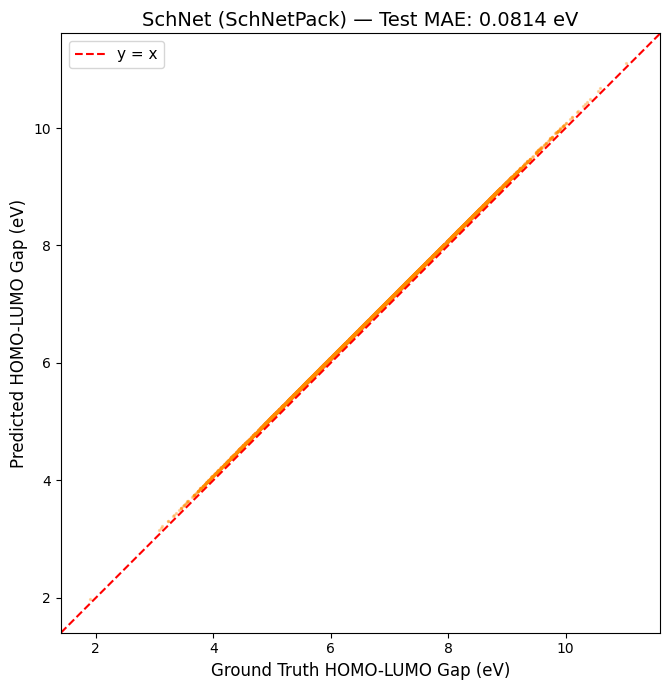

Figure saved to /content/drive/MyDrive/24788-miniproject/figures/schnet_pred_vs_true.png


In [14]:
@torch.no_grad()
def get_predictions_spk(
    model: torch.nn.Module,
    dataloader,
    gap_mean: float,
    device: str = 'cpu',
) -> tuple:
    """
    Return (predictions_eV, true_eV) numpy arrays from a DataLoader.
    Restores targets from normalized space by adding gap_mean.
    """
    model = model.to(device)
    model.eval()
    all_preds, all_trues = [], []
    for batch in dataloader:
        batch = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        result  = model(batch)
        pred_eV = result[QM9.gap].squeeze(-1).double()
        true_eV = (batch[QM9.gap].squeeze(-1) + gap_mean).double()
        all_preds.append(pred_eV.cpu())
        all_trues.append(true_eV.cpu())
    return (
        torch.cat(all_preds).numpy(),
        torch.cat(all_trues).numpy(),
    )


preds, trues = get_predictions_spk(
    best_model, qm9data.test_dataloader(), GAP_MEAN
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(trues, preds, s=2, alpha=0.3, c='darkorange')
lims = [
    min(trues.min(), preds.min()) - 0.5,
    max(trues.max(), preds.max()) + 0.5,
]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Ground Truth HOMO-LUMO Gap (eV)', fontsize=12)
ax.set_ylabel('Predicted HOMO-LUMO Gap (eV)', fontsize=12)
ax.set_title(f'SchNet (SchNetPack) — Test MAE: {test_mae:.4f} eV', fontsize=14)
ax.legend(fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()

FIGURES_DIR = os.path.join(DRIVE_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
fig_path = os.path.join(FIGURES_DIR, 'schnet_pred_vs_true.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {fig_path}")

## 9. Embedding Extraction

Extract graph-level embeddings from the trained SchNet model for t-SNE
visualization.

In [15]:
@torch.no_grad()
def extract_embeddings_spk(
    model: torch.nn.Module,
    dataloader,
    gap_mean: float,
    device: str = 'cpu',
    max_samples: int = 2000,
) -> tuple:
    """
    Extract graph-level embeddings and de-normalized gap labels.

    SchNet produces atom-wise representations stored in
    results["scalar_representation"] with shape [N_atoms, n_atom_basis].
    We sum-pool over atoms per molecule using the _idx_m batch assignment
    tensor to get graph-level embeddings of shape [N_molecules, n_atom_basis].

    Returns:
        embeddings : np.ndarray [N, n_atom_basis]
        labels_eV  : np.ndarray [N]  (de-normalized HOMO-LUMO gap in eV)
    """
    model = model.to(device)
    model.eval()
    all_embeddings, all_labels = [], []
    n_collected = 0

    for batch in dataloader:
        if n_collected >= max_samples:
            break
        batch = {
            k: v.to(device) if isinstance(v, torch.Tensor) else v
            for k, v in batch.items()
        }
        inputs = model.initialize_derivatives(batch)
        for m in model.input_modules:
            inputs = m(inputs)
        inputs = model.representation(inputs)

        # Atom-wise features: [N_atoms_in_batch, n_atom_basis]
        atom_repr = inputs["scalar_representation"]   # (N_atoms, F)
        idx_m = batch["_idx_m"]                    # (N_atoms,) mol index
        batch_size = int(idx_m.max().item()) + 1

        # Sum-pool per molecule: scatter_add over atom dimension
        graph_repr = torch.zeros(
            batch_size, atom_repr.shape[-1],
            device=device, dtype=atom_repr.dtype,
        )
        graph_repr.scatter_add_(
            0,
            idx_m.unsqueeze(-1).expand_as(atom_repr),
            atom_repr,
        )

        true_eV = (batch[QM9.gap].squeeze(-1) + gap_mean).float()
        all_embeddings.append(graph_repr.float().cpu())
        all_labels.append(true_eV.cpu())
        n_collected += batch_size

    embeddings = torch.cat(all_embeddings).numpy()[:max_samples]
    labels_eV  = torch.cat(all_labels).numpy()[:max_samples]
    return embeddings, labels_eV


# Extract from test set (2 000 samples is sufficient for t-SNE)
embeddings, labels_eV = extract_embeddings_spk(
    best_model, qm9data.test_dataloader(), GAP_MEAN, max_samples=2000
)
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape:     {labels_eV.shape}")
print(f"Gap range: [{labels_eV.min():.3f}, {labels_eV.max():.3f}] eV")

# Save for Phase 4 t-SNE analysis (analysis/tsne_visualization.py)
EMBED_DIR = os.path.join(DRIVE_DIR, 'embeddings')
os.makedirs(EMBED_DIR, exist_ok=True)
np.save(os.path.join(EMBED_DIR, 'schnet_embeddings.npy'), embeddings)
np.save(os.path.join(EMBED_DIR, 'schnet_labels_eV.npy'),  labels_eV)
print(f"Saved to {EMBED_DIR}/schnet_embeddings.npy")

Embeddings shape: (2000, 128)
Labels shape:     (2000,)
Gap range: [3.855, 12.559] eV
Saved to /content/drive/MyDrive/24788-miniproject/embeddings/schnet_embeddings.npy


## 10. Summary

The SchNet variant (SchNetPack 2.0) has been trained and evaluated.
Key outputs saved to Google Drive:
- **Best checkpoint:** `schnetpack_checkpoints/schnetpack_best/schnetpack_best.ckpt`
- **Resume checkpoint:** `schnetpack_checkpoints/schnetpack_best/last.ckpt`
- **Inference model:** `schnetpack_checkpoints/best_inference_model/`
- **Config:** `schnetpack_configs/schnetpack_config.json`
- **Figure:** `figures/schnet_pred_vs_true.png`
- **Embeddings:** `embeddings/schnet_embeddings.npy`
- **W&B run:** `24788-miniproject/SchNetPack`

### GCN vs SchNet comparison
| Aspect | GCN | SchNet |
|---|---|---|
| Edges | Bond topology (data.edge\_index) | Radius graph (10 Å cutoff) |
| Node input | 11-dim features (data.x) | Atomic number embedding |
| Convolution | Normalised adjacency | Continuous-filter (cfconv) |
| Pooling | Mean | Sum |
| 3D geometry | No | Yes |